# Import Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller

# Read data

<Axes: title={'center': 'Raw data'}, xlabel='Month'>

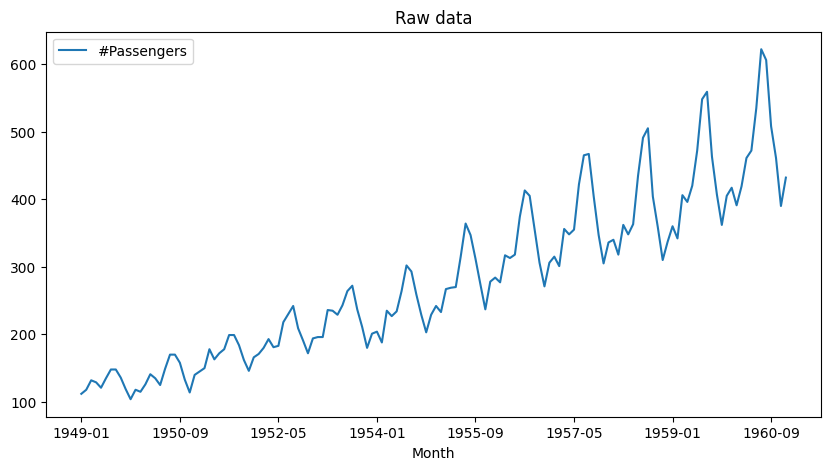

In [52]:
data = pd.read_csv("AirPassengers.csv",
                   header=0, index_col=0)
data.plot(title = "Raw data", figsize=(10,5))

## Checking for stationarity (definition wise)

In [60]:
# splitting time-series data into three parts

parts = int(len(data)/3)

part_1, part_2, part_3 = data[0:parts], data[parts:(parts*2)], data[(parts*2):(parts*3)]
mean_1, mean_2, mean_3 = part_1.mean(), part_2.mean(), part_3.mean()
var_1, var_2, var_3 = part_1.var(), part_2.var(), part_3.var()

# printing the mean of three groups
print("mean1={}, mean2={}, mean2={}".format(mean_1.values[0], mean_2.values[0], mean_3.values[0]))

# printing the variance of three groups
print("variance1={}, variance2={}, variance2={}".format(var_1.values[0], var_2.values[0], var_3.values[0]))

mean1=158.375, mean2=269.0416666666667, mean2=413.4791666666667
variance1=1094.6648936170213, variance2=3105.9982269503544, variance2=6161.999556737588


> The output clearly implies that the mean and variance of the three groups are considerably different from each other describing the data is non-stationary.

<Axes: title={'center': 'log of raw data'}, xlabel='Month'>

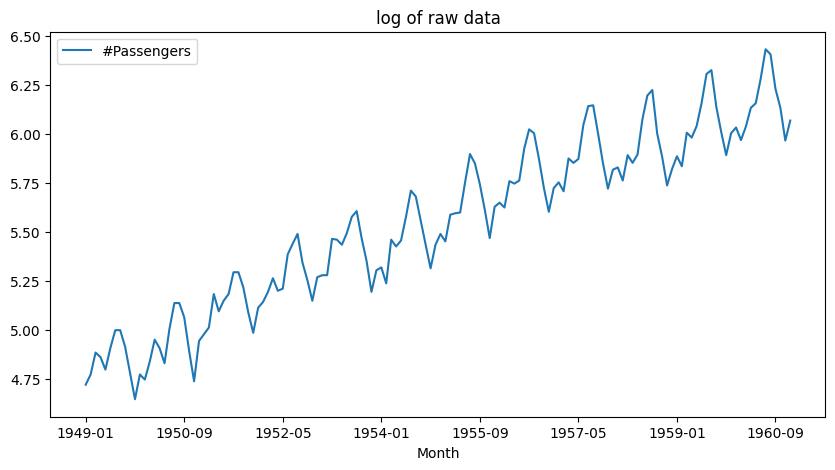

In [64]:
# lets try by taking log of above data

np.log(data).plot(title = "log of raw data", figsize=(10,5))

In [67]:
# splitting time-series data into three parts
log_value = np.log(data)

parts = int(len(log_value)/3)

part_1, part_2, part_3 = log_value[0:parts], log_value[parts:(parts*2)], log_value[(parts*2):(parts*3)]
mean_1, mean_2, mean_3 = part_1.mean(), part_2.mean(), part_3.mean()
var_1, var_2, var_3 = part_1.var(), part_2.var(), part_3.var()

# printing the mean of three groups
print("mean1={}, mean2={}, mean2={}".format(mean_1.values[0], mean_2.values[0], mean_3.values[0]))

# printing the variance of three groups
print("variance1={}, variance2={}, variance2={}".format(var_1.values[0], var_2.values[0], var_3.values[0]))

mean1=5.0439107377437, mean2=5.574732792583696, mean2=6.007884345268219
variance1=0.042901117410910884, variance2=0.04051159084053209, variance2=0.033399648158998464


> The mean and variance seems somewhat equal across the three groups ...

## Augmented Dickey Fuller Test (test for stationarity)

> * Ho (Null Hypothesis): The time series data is non-stationary
> * H1 (alternate Hypothesis): The time series data is stationary

In [68]:
res = adfuller(data)

# Printing the statistical result of the adfuller test
print('Augmneted Dickey_fuller Statistic: %f' % res[0])
print('p-value: %f' % res[1])

Augmneted Dickey_fuller Statistic: 0.815369
p-value: 0.991880


In [69]:
res = adfuller(np.log(data))

# Printing the statistical result of the adfuller test
print('Augmneted Dickey_fuller Statistic: %f' % res[0])
print('p-value: %f' % res[1])

Augmneted Dickey_fuller Statistic: -1.717017
p-value: 0.422367


# Time series Decomposition

In [70]:
# converting index to datetime
data.index = pd.to_datetime(data.index)
data.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [71]:
import statsmodels.api as sm

df = data.copy()
# Seasonal adjustment
result = sm.tsa.seasonal_decompose(df['#Passengers'].values, 
                                   model='multiplicative', 
                                   period=12)

In [72]:
df['Trend'] = pd.Series(result.trend, index=df.index)
df['Seasonal'] = pd.Series(result.seasonal, index=df.index)
df['Residual'] = pd.Series(result.resid, index=df.index)


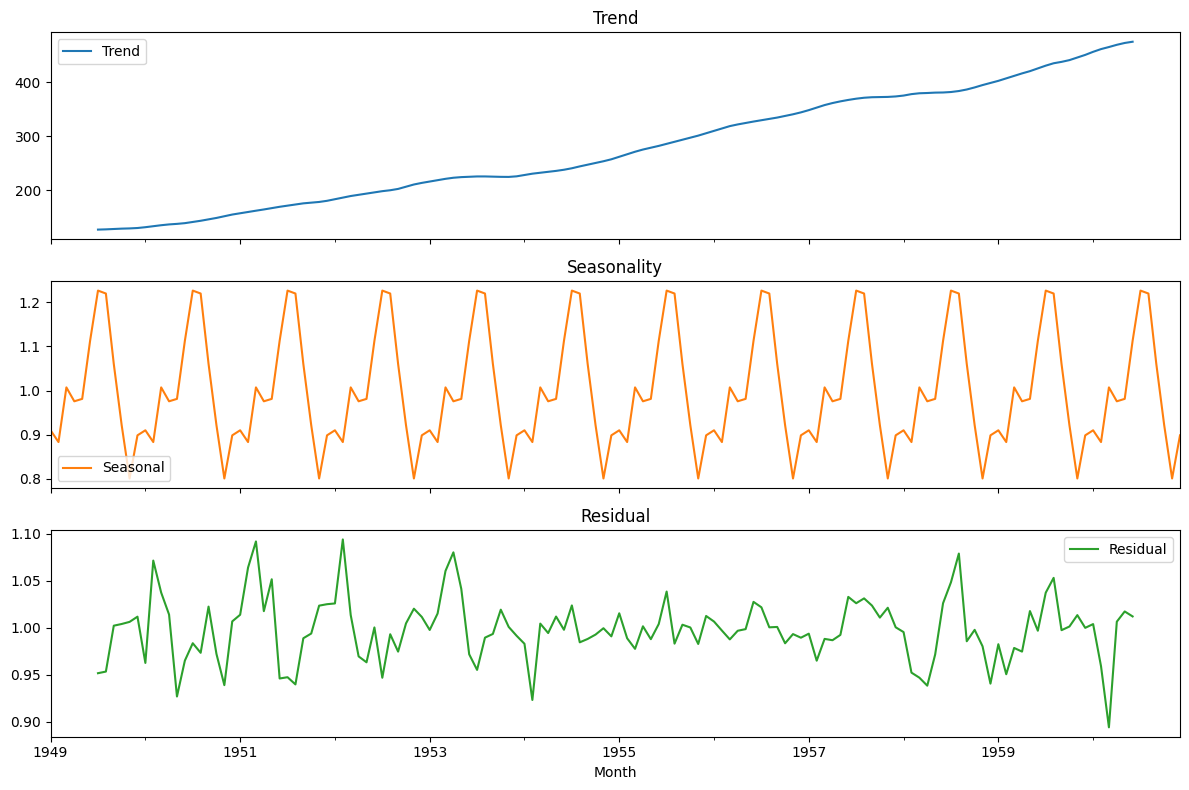

In [73]:
df[['Trend', 'Seasonal', 'Residual']].plot(subplots=True, 
                                           figsize=(12, 8), 
                                           title=['Trend', 'Seasonality', 'Residual'])
plt.tight_layout()
plt.show()

# Time series forecasting models

## Simple Moving Average Model (SMA)

### Importing libraries

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import yfinance as yf

<Axes: title={'center': 'Close price of AMD since 1-Jan-2020'}, xlabel='Date'>

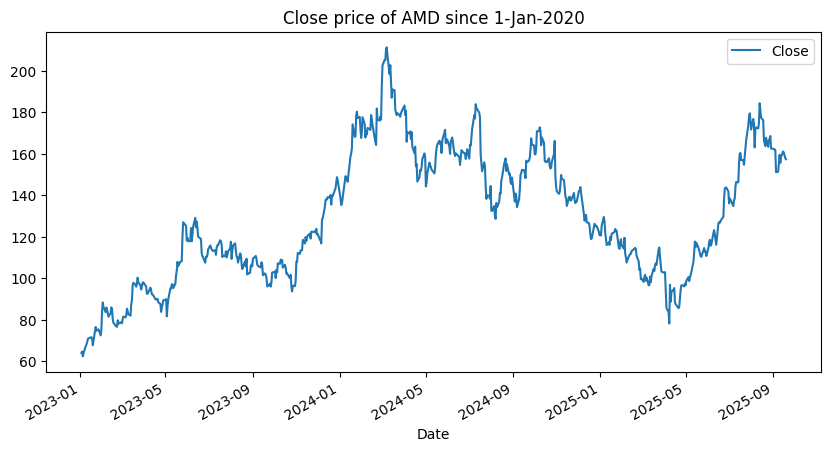

In [98]:
amd = yf.Ticker("AMD")

# getting the historical market data
amd_values = amd.history(start="2023-01-01")

# Plotting the close price of AMD
amd_values[['Close']].plot(title = "Close price of AMD since 1-Jan-2020", figsize=(10,5))

### lets calculate 10 day rolling average

<Axes: title={'center': 'Close and rolling_10 plot for AMD'}, xlabel='Date'>

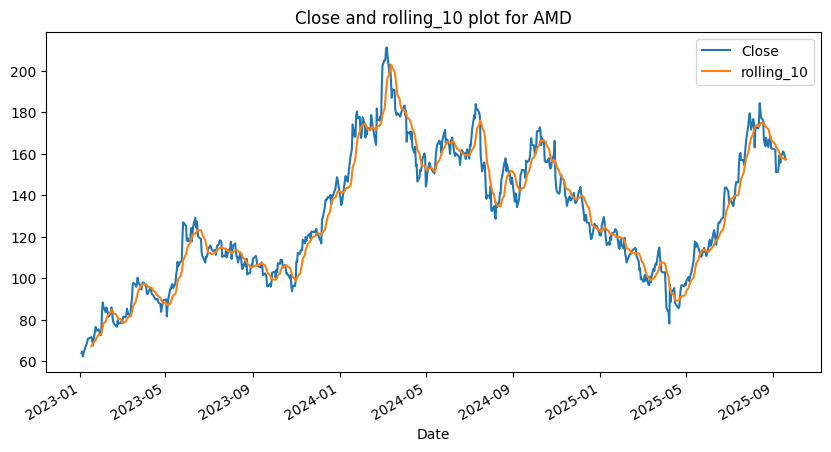

In [99]:
amd_values["rolling_10"]=amd_values["Close"].rolling(10).mean()
amd_values[["Close", "rolling_10"]].plot(title = "Close and rolling_10 plot for AMD", 
                                         figsize=(10,5))

### forecasting in SMA model (window_size = 10)

In [108]:
rolling_window

Date
2025-09-08 00:00:00-04:00    151.410004
2025-09-09 00:00:00-04:00    155.820007
2025-09-10 00:00:00-04:00    159.539993
2025-09-11 00:00:00-04:00    155.669998
2025-09-12 00:00:00-04:00    158.570007
2025-09-15 00:00:00-04:00    161.160004
2025-09-16 00:00:00-04:00    160.460007
2025-09-17 00:00:00-04:00    159.160004
2025-09-18 00:00:00-04:00    157.919998
2025-09-19 00:00:00-04:00    157.389999
Name: Close, dtype: float64

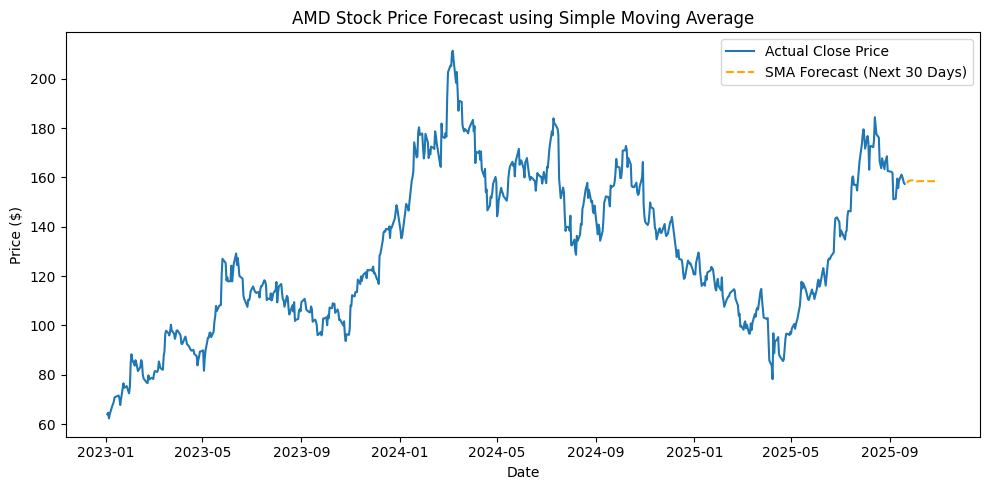

In [110]:
window = 10
forecast_horizon = 30

rolling_window = amd_values["Close"].iloc[-window:].copy()
forecasted_values = []

# Generate 30-day SMA forecast
for _ in range(forecast_horizon):
    next_forecast = rolling_window.mean()
    forecasted_values.append(next_forecast)
    
    # Update rolling window
    rolling_window = pd.concat([rolling_window, pd.Series([next_forecast])], ignore_index=True)
    rolling_window = rolling_window.iloc[-window:]

# create forecast dates
last_date = amd_values['Close'].copy().index[-1]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), 
                               periods=forecast_horizon, 
                               freq='B')    #'B' for business days

# Combine into a forecast series
forecast_series = pd.Series(forecasted_values, 
                            index=forecast_dates)


# Plot actual and forecasted values
plt.figure(figsize=(10, 5))
plt.plot(amd_values['Close'], label='Actual Close Price')
plt.plot(forecast_series, label='SMA Forecast (Next 30 Days)', linestyle='--', color='orange')
plt.title('AMD Stock Price Forecast using Simple Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Naive Forecast Model

> next value = last observed value

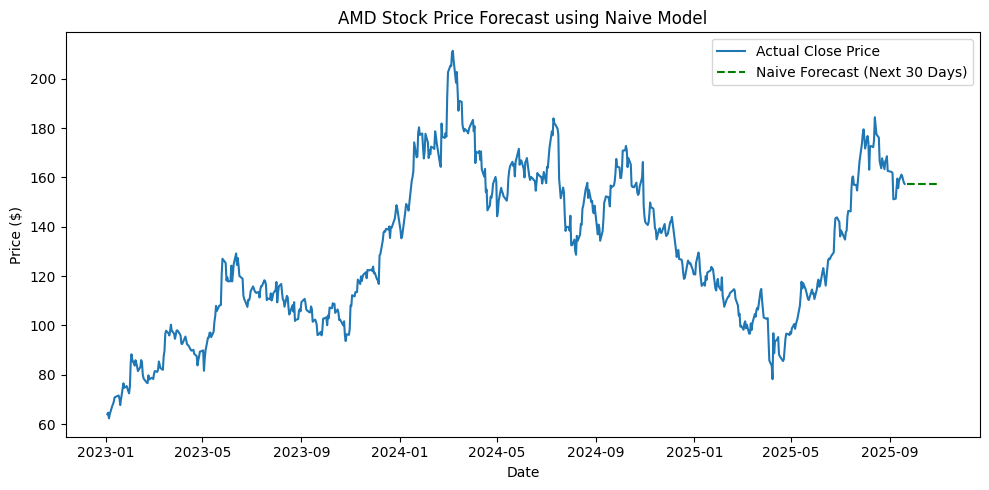

In [117]:
# Naive Forecast Model: next value = last observed value
naive_forecast_value = amd_values['Close'].iloc[-1]
naive_forecast = pd.Series(
    [naive_forecast_value] * forecast_horizon,
    index=forecast_dates
)

# Plot actual and naive forecasted values
plt.figure(figsize=(10, 5))
plt.plot(amd_values['Close'], label='Actual Close Price')
plt.plot(naive_forecast, label='Naive Forecast (Next 30 Days)', linestyle='--', color='green')
plt.title('AMD Stock Price Forecast using Naive Model')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Seasonal Naive Model

In [126]:
 np.tile(seasonal_pattern, 
                                         int(np.ceil(forecast_horizon / seasonal_period)))[:forecast_horizon]

array([148.28999329, 156.74000549, 155.94999695, 156.75      ,
       158.32000732, 162.02000427, 167.49000549, 164.3500061 ,
       164.08000183, 159.75      , 159.77999878, 162.8500061 ,
       170.8999939 , 170.97000122, 172.80000305, 171.02000427,
       164.17999268, 167.88999939, 165.27000427, 156.63999939,
       156.13000488, 156.25      , 155.97000122, 157.8999939 ,
       154.08999634, 152.91000366, 153.44000244, 156.22999573,
       159.91999817, 166.25      ])

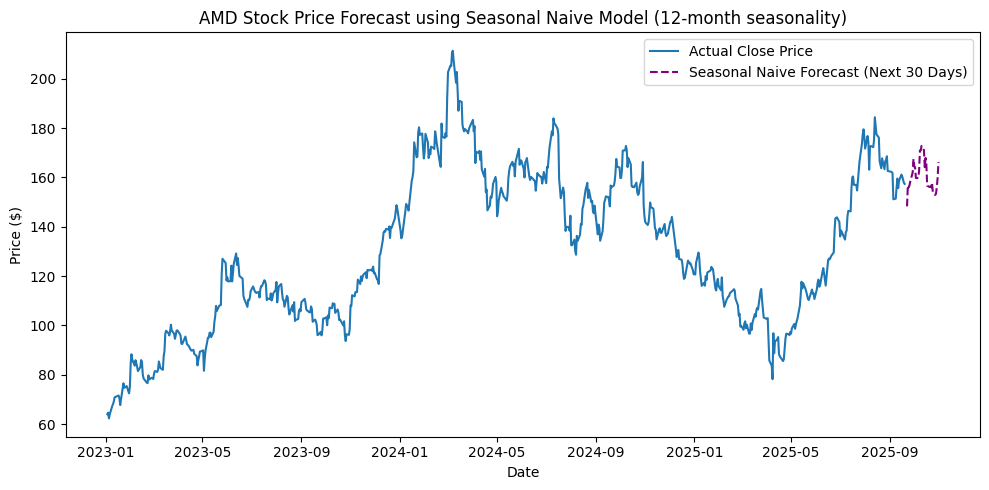

In [130]:
# Seasonal Naive Forecast Model (seasonal cycle = 12 months)

# Calculate the number of business days in 12 months (approximate)
seasonal_period = 252  # typical number of trading days in a year

# Get the last 'seasonal_period' closing prices as the seasonal pattern
seasonal_pattern = amd_values['Close'].iloc[-seasonal_period:].values

# Repeat the seasonal pattern to cover the forecast horizon
### create seasonal_pattern array int(np.ceil...) times and keep forecast horizon values only
seasonal_naive_forecast_values = np.tile(seasonal_pattern, 
                                         int(np.ceil(forecast_horizon / seasonal_period)))[:forecast_horizon]

# Create forecast series with the same forecast_dates as previous models
seasonal_naive_forecast = pd.Series(seasonal_naive_forecast_values, 
                                    index=forecast_dates)

# Plot actual and seasonal naive forecasted values
plt.figure(figsize=(10, 5))
plt.plot(amd_values['Close'], label='Actual Close Price')
plt.plot(seasonal_naive_forecast, label='Seasonal Naive Forecast (Next 30 Days)', linestyle='--', color='purple')
plt.title('AMD Stock Price Forecast using Seasonal Naive Model (12-month seasonality)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Weighted moving average model (WMA)

In [136]:
# Weighted Moving Average (WMA) Model
# Define weights for the window (most recent gets highest weight)
weights = np.arange(1, window + 1) ### ... [1,2,3,4,.....10] --> these will be weights in the window
weights = weights / weights.sum()  # Normalize weights

# Calculate weighted moving average for the last window
wma_forecasted_values = []
wma_rolling_window = amd_values["Close"].iloc[-window:].copy()

for _ in range(forecast_horizon):
    wma_next = np.dot(wma_rolling_window.values, weights)
    wma_forecasted_values.append(wma_next)
    
    # Update rolling window
    wma_rolling_window = pd.concat([wma_rolling_window, pd.Series([wma_next])], ignore_index=True)
    wma_rolling_window = wma_rolling_window.iloc[-window:]

# Create forecast series
wma_forecast_series = pd.Series(wma_forecasted_values, index=forecast_dates)

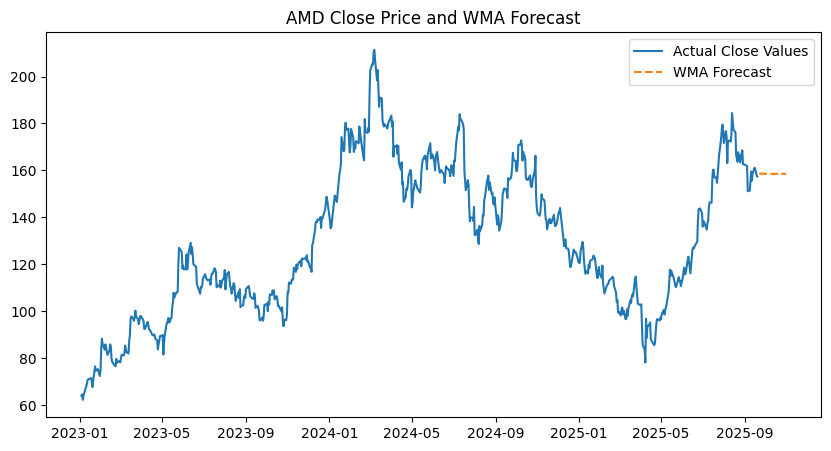

In [142]:
plt.figure(figsize=(10, 5))
plt.plot(amd_values["Close"], label="Actual Close Values")
plt.plot(wma_forecast_series, label="WMA Forecast", linestyle="--")
plt.title("AMD Close Price and WMA Forecast")
plt.legend()
plt.show()

## Exponential Moving Average (EMA)

Smoothed value at (t+1) depends upon actual value and smoothed values at previous time step.
$$S_\text{t+1}=\alpha*y_t + (1-\alpha)*S_t$$

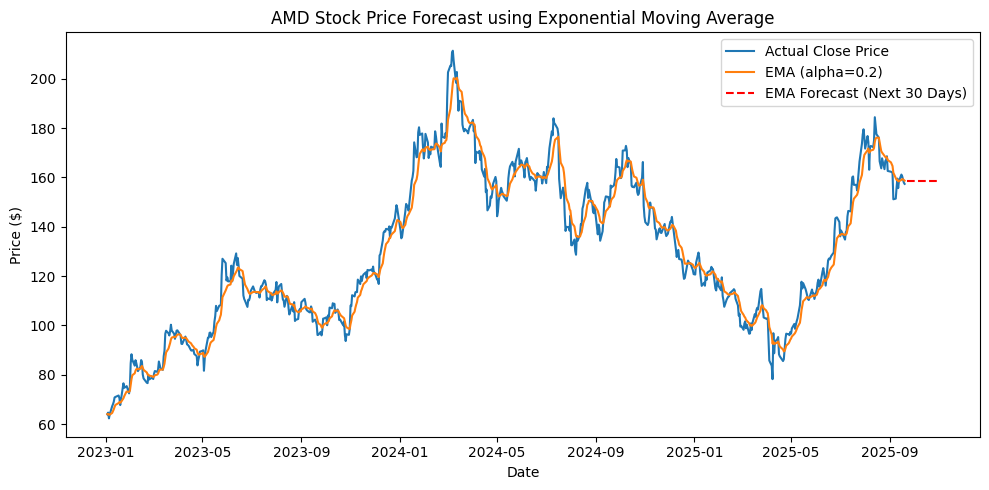

In [143]:
# Exponential Moving Average (EMA) Forecasting Model

# Define smoothing factor alpha (commonly between 0.05 and 0.3 for daily data)
alpha = 0.2

# Calculate EMA for the historical data
amd_values['EMA'] = amd_values['Close'].ewm(alpha=alpha, adjust=False).mean()

# Forecast next N days using last EMA value as forecast (standard for simple EMA forecasting)
ema_forecast_value = amd_values['EMA'].iloc[-1]
ema_forecast = pd.Series([ema_forecast_value] * forecast_horizon, index=forecast_dates)

# Plot actual, EMA, and EMA forecast
plt.figure(figsize=(10, 5))
plt.plot(amd_values['Close'], label='Actual Close Price')
plt.plot(amd_values['EMA'], label=f'EMA (alpha={alpha})')
plt.plot(ema_forecast, label='EMA Forecast (Next 30 Days)', linestyle='--', color='red')
plt.title('AMD Stock Price Forecast using Exponential Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.show()

## Holts Linear Trend Model

$y_\text{t+ time step} = \text{level equation} + \text{time step}*\text{trend equation}$

In [147]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt

# Read in the data
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

print(train.shape, test.shape)

(116, 2) (28, 2)


In [149]:
# Fit simple model and get forecasts
model_simple = SimpleExpSmoothing(train['#Passengers']).fit(optimized=True)
forecasts_simple = model_simple.forecast(len(test))

# Fit Holt's model and get forecasts
model_holt = Holt(train['#Passengers'], damped_trend=True).fit(optimized=True)
forecasts_holt = model_holt.forecast(len(test))

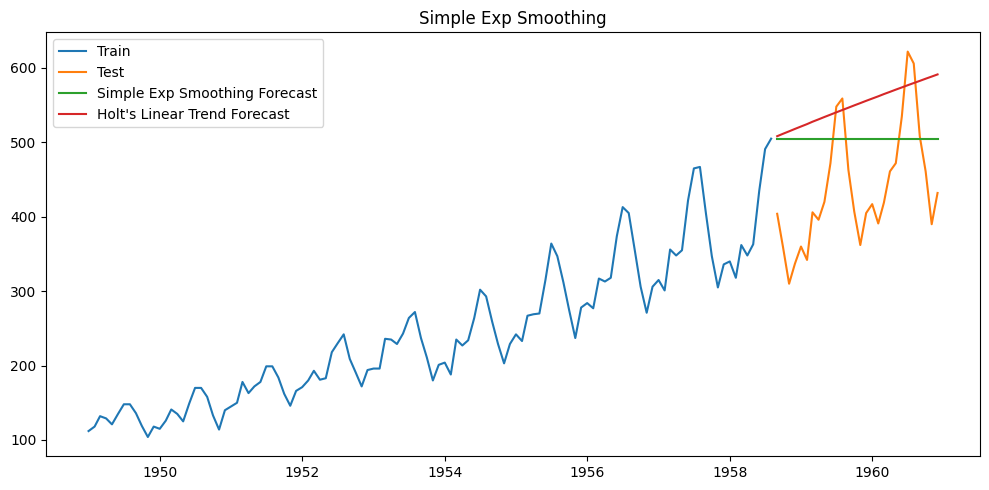

In [154]:
fig, axes = plt.subplots(1, 1, figsize=(10, 5))

# Plot for Simple Exponential Smoothing
axes.plot(train['Month'], train['#Passengers'], label='Train')
axes.plot(test['Month'], test['#Passengers'], label='Test')
axes.plot(test['Month'], forecasts_simple, label='Simple Exp Smoothing Forecast')
axes.plot(test['Month'], forecasts_holt, label="Holt's Linear Trend Forecast")
axes.set_title('Simple Exp Smoothing')
axes.legend()

plt.tight_layout()
plt.show()

# Time series model Analysis - Residual Analysis

Residuals should,
> * Show very little or no autocorrelation or partial autocorrelation. 
>   * If they have any form of correlation, then the model has missed some information that’s in the data. We can use the Ljung–Box statistical test to determine if the residuals are indeed correlated.
> * The mean of the residuals should be zero, otherwise the forecast will be biased. In reality, this is quite easy to adjust for by simply adding or subtracting the bias from the forecasts.

In [157]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Read in the data
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Fit Holt Winters model and get forecasts
model = ExponentialSmoothing(train['#Passengers'], 
                             trend='mul', 
                             seasonal='mul',
                               seasonal_periods=12).fit(optimized=True)
forecasts = model.forecast(len(test))

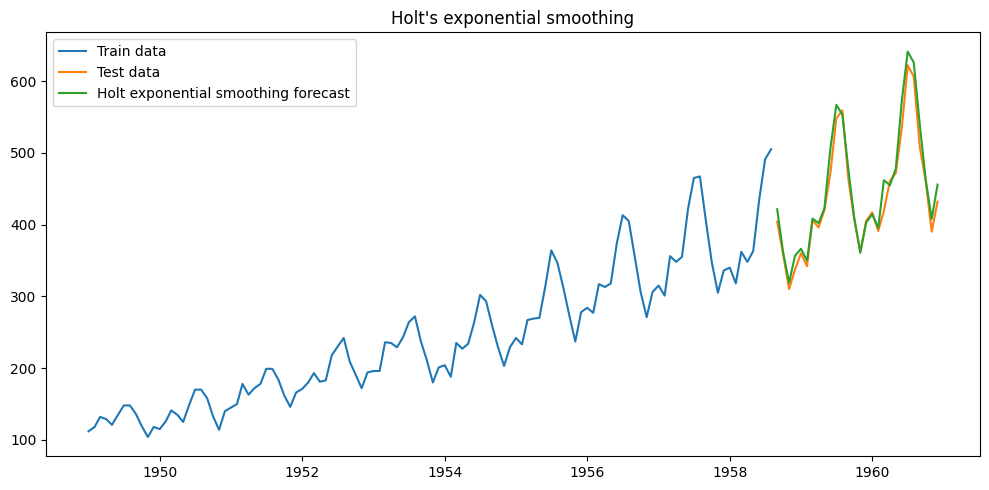

In [163]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
ax.plot(train["Month"], train["#Passengers"], label="Train data")
ax.plot(test["Month"], test["#Passengers"], label="Test data")
ax.plot(test["Month"], forecasts.values, label="Holt exponential smoothing forecast")

ax.set_title("Holt's exponential smoothing")
ax.legend()

plt.tight_layout()
plt.show()

In [166]:
train["fittedvalues"] = model.fittedvalues
train["residuals"] = model.resid

train.head()

C:\Users\Shivam Sharma\AppData\Local\Temp\ipykernel_5396\2562647389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["fittedvalues"] = model.fittedvalues
C:\Users\Shivam Sharma\AppData\Local\Temp\ipykernel_5396\2562647389.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train["residuals"] = model.resid


,Month,#Passengers,fittedvalues,residuals
0,1949-01-01,112,112.001050,-0.001050
1,1949-02-01,118,119.392699,-1.392699
2,1949-03-01,132,132.484419,-0.484419
3,1949-04-01,129,126.799177,2.200823
4,1949-05-01,121,118.553695,2.446305


### Residual correlation

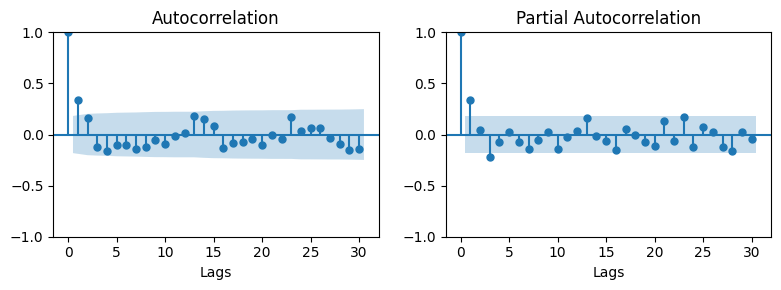

In [167]:
# Import packages
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot ACF and PACF
fig, ax = plt.subplots(1,2,figsize=(8,3))
plot_acf(train['residuals'], lags=30, ax=ax[0])
ax[0].set_xlabel('Lags')

plot_pacf(train['residuals'], lags=30, ax=ax[1])
ax[1].set_xlabel('Lags')
plt.tight_layout()
plt.show()

### Ljung-Box Test

A more quantitive way to determine if the residuals are correlated is to carry out the Ljung–Box statistical test:

> - H_0: Residuals are independently distributed.
> - H_a: Residuals are not independently distributed and exhibit serial correlation.

In [168]:
# Import packages
from statsmodels.stats.diagnostic import acorr_ljungbox

# Carry out Ljung-Box test
print(acorr_ljungbox(train['residuals'], return_df=True))

      lb_stat  lb_pvalue
1   13.916668   0.000191
2   16.931210   0.000211
3   18.860530   0.000292
4   22.061065   0.000195
5   23.398159   0.000283
6   24.627453   0.000400
7   27.058900   0.000325
8   29.030848   0.000313
9   29.343985   0.000567
10  30.414637   0.000733


### Histogram of Residuals

> A histogram of the residuals will determine if they have a mean of zero and are symmetric (no bias)

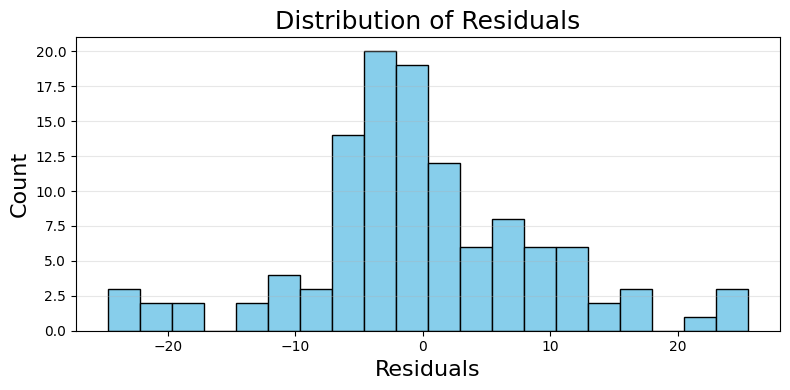

-0.022976911851162494


In [169]:
# Plot histogram of the residuals using matplotlib
plt.figure(figsize=(8, 4))
plt.hist(train['residuals'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Residuals', fontsize=18)
plt.xlabel('Residuals', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Mean of residuals
print(train['residuals'].mean())

# Autoregressive Model for Time series

Autoregression is when you forecast a time series using some linear weighted combination of the previous values (lags) of that time series. As we are regressing a target value against itself, it is called auto-regression. Mathematically,
$$
y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \epsilon_t
$$

## Requirements ???

> - To build an autoregressive model, it is recommended to have a stationary time series. 
>   - The reason we need stationarity it to ensure the statistical properties of the time series is consistent through time, rendering it easier to model.
>   - Stationarity can be achieved by stabilising the trend through differencing and stabilising the variance through a Logarithm or Box-Cox transform.

<Axes: title={'center': 'Air Passenger raw data'}, xlabel='Month'>

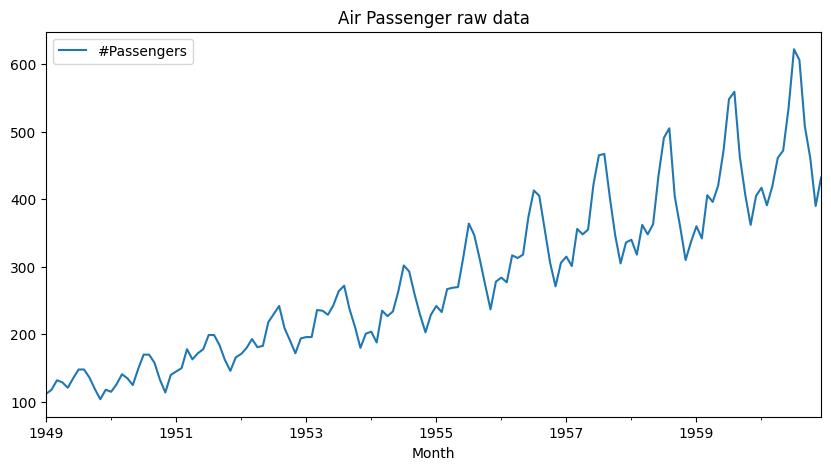

In [170]:
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index("Month", inplace=True)

data.plot(figsize=(10,5), title = "Air Passenger raw data")

## Remove the trend --> boxcox + differencing

<Axes: title={'center': 'Air Passenger data after boxcox + differencing'}, xlabel='Month'>

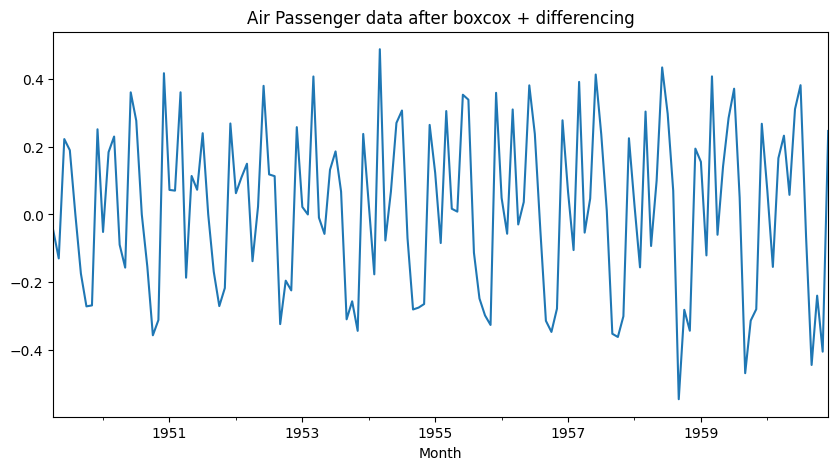

In [173]:
from scipy.stats import boxcox

# Make the target stationary
data['Passengers_boxcox'], lam = boxcox(data['#Passengers'])
data["Passenger_stationary"] = data["Passengers_boxcox"].diff()
data.dropna(inplace=True)

# Plot the stationary airline passenger data
data["Passenger_stationary"].plot(figsize=(10,5), title = "Air Passenger data after boxcox + differencing")

## Order selection ???

### ACF and PACF plot

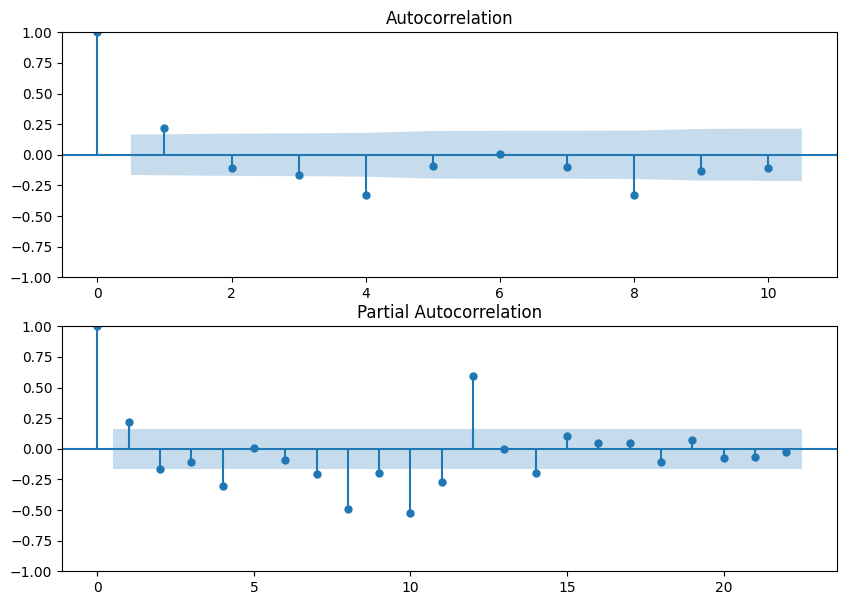

In [177]:
def plot_acf_pacf(timeseries):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
    plot_acf(timeseries, ax=ax1, lags = 10)
    plot_pacf(timeseries, ax=ax2, method='ywm')
    plt.show()


# Plotting ACF and PACF of the closing value time series
plot_acf_pacf(data["Passenger_stationary"])

> - The lags outside the blue shaded region are classed as significantly significant and should be included as the features for our autoregressive model. From the above plot, it seems lags 1, 2, 4, 7, 8, 9, 10, 11, 12 and 14 are significant. 
> - Notice how lag 12 has the largest peak. This is because our time series is indexed by month and has a yearly seasonality, hence lag 12 is an exact year difference.

> * However, for building our model we will use the recommended approach of simply iterating over all the possible combinations of lags and choose the best model from that analysis. As our dataset is quite small, this is easily computationally feasible.

## Model Fitting

In [178]:
# Import packages
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Build AR model
selector = ar_select_order(train['Passenger_stationary'], 15)
model = AutoReg(train['Passenger_stationary'], lags=selector.ar_lags).fit()

c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


## Predictions time

In [179]:
# Import packages
from scipy.special import inv_boxcox

# Get forecasts and convert to actual passenger volumes
transformed_forecasts = list(model.forecast(steps=len(test)))
boxcox_forecasts = []
for idx in range(len(test)):
    if idx == 0:
        boxcox_forecast = transformed_forecasts[idx] + train['Passengers_boxcox'].iloc[-1]
    else:
        boxcox_forecast = transformed_forecasts[idx] + boxcox_forecasts[idx-1]

    boxcox_forecasts.append(boxcox_forecast)

forecasts = inv_boxcox(boxcox_forecasts, lam)

c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


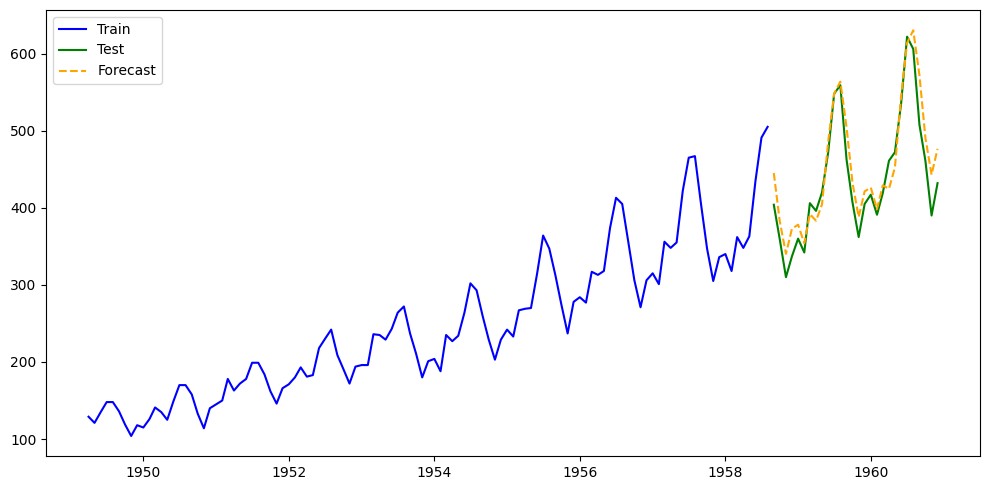

In [184]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train['#Passengers'], label='Train', color='blue')
plt.plot(test.index, test['#Passengers'], label='Test', color='green')

# Plot forecast
plt.plot(test.index, forecasts, label='Forecast', linestyle='--', color='orange')
plt.legend()
plt.tight_layout()
plt.show()

# Moving Average Model for Time series

> We can forecast using past forecast errors instead which is known as the moving-average (MA) model.
$$
y_t = \mu + \epsilon_t + \theta_1 \epsilon_{t-1} + \theta_2 \epsilon_{t-2} + \ldots + \theta_q \epsilon_{t-q}
$$

<Axes: title={'center': 'Raw data of Air Passenger'}, xlabel='Month'>

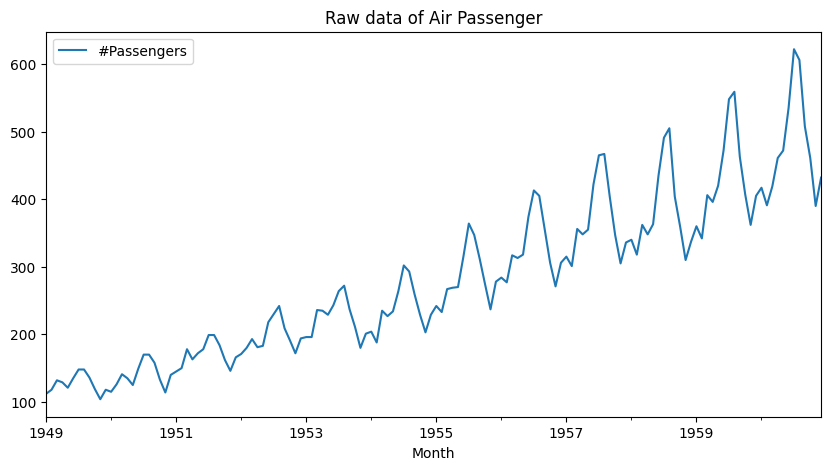

In [185]:
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])

data.set_index("Month", inplace=True)
data.plot(title = "Raw data of Air Passenger", figsize=(10,5))

<Axes: title={'center': 'Stationary transformation applied'}, xlabel='Month'>

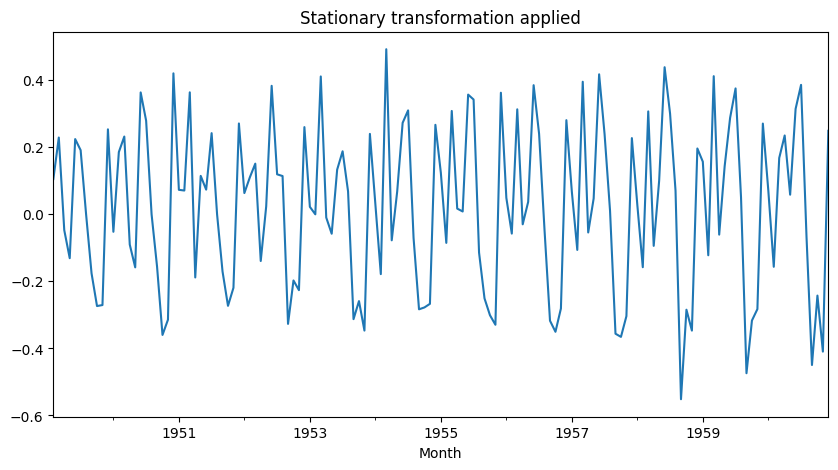

In [186]:
from scipy.stats import boxcox

# Make the target stationary
data['Passengers_boxcox'], lam = boxcox(data['#Passengers'])
data["Passenger_stationary"] = data["Passengers_boxcox"].diff()
data.dropna(inplace=True)

# Plot the stationary airline passenger data
data["Passenger_stationary"].plot(title = "Stationary transformation applied", figsize=(10,5))

## Fitting the MA model

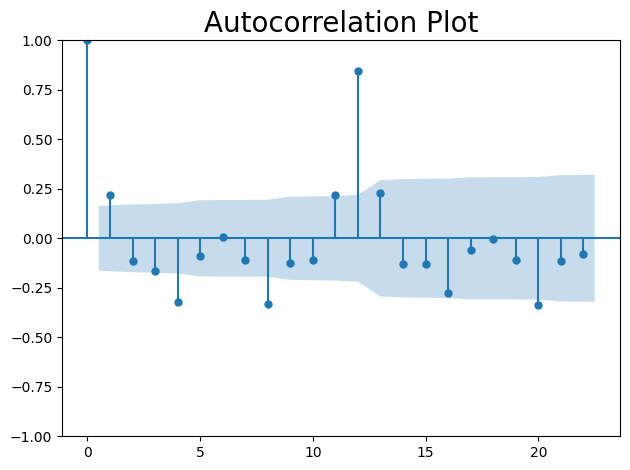

In [189]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot autocorrelation
plot_acf(data['Passenger_stationary'])
plt.title('Autocorrelation Plot', fontsize=20)
plt.tight_layout()
plt.show()

> - The blue region signifies where the values are no longer statistically significant. From the above plot, we can that see that the last significant lag is the 13th. 
>   - Therefore, our model order for the MA model will be 13. 
> - Unfortunately, no direct MA model function or package exists in Python, so we are going to use the ARIMA function from statsmodels and set every component to zero apart from the moving average orders.

In [190]:
# Import packages
from statsmodels.tsa.arima.model import ARIMA

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Train model
model = ARIMA(train['Passenger_stationary'], order=(0, 0, 13)).fit()

c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters foun

## Results ???

In [192]:
from scipy.special import inv_boxcox

# Get forecasts and convert to actual passenger volumes
transformed_forecasts = list(model.forecast(steps=len(test)))
boxcox_forecasts = []
for idx in range(len(test)):
    if idx == 0:
        boxcox_forecast = transformed_forecasts[idx] + train['Passengers_boxcox'].iloc[-1]
    else:
        boxcox_forecast = transformed_forecasts[idx] + boxcox_forecasts[idx-1]

    boxcox_forecasts.append(boxcox_forecast)

forecasts = inv_boxcox(boxcox_forecasts, lam)

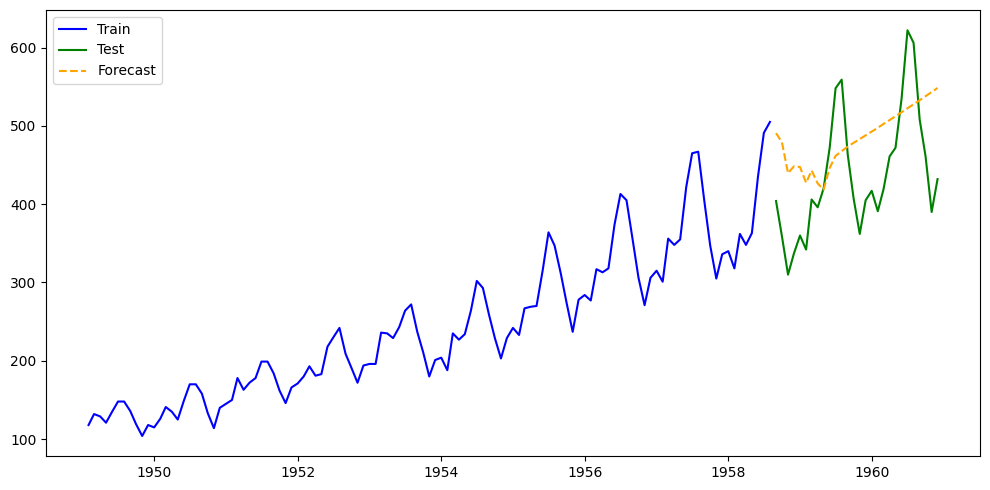

In [196]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train['#Passengers'], label='Train', color='blue')
plt.plot(test.index, test['#Passengers'], label='Test', color='green')

# Plot forecast
plt.plot(test.index, forecasts, label='Forecast', linestyle='--', color='orange')
plt.legend()
plt.tight_layout()
plt.show()

# ARIMA

> -  ARIMA stands for AutoRegressive Integrated Moving Average is basically just a combination of the three (in reality two) components:
>   - AutoRegressive (AR):
>     - This is just autoregression, where we forecast future values using a linear combination of the previously observed values.
>   - Integrated (I):
>     - The middle part of the ARIMA model is named integrated. This is the number (order d) of differencing required to make the time series stationary.
>     - Stationarity is where the time series has a constant mean and variance, meaning the statistical properties of the series does not change through time. Differencing de-trends a time series and tends to make the mean constant. We can apply differencing several times, but often the series is sufficiently stationary after a single differencing step.
>   - Moving Average (MA):
>     - The last component is the moving average where we forecast using past forecast errors instead of the actual observed values.

## Order selection ???

> - Method 1
>   - d --> ADF test
>   - p --> PACF
>   - q --> ACF
> - Method 2
>   - Iterate over all the possible combinations of orders and choose the model with the best score against a metric such as Akaike’s Information Criterion (AIC).


In [197]:
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index("Month", inplace=True)

In [198]:
from scipy.stats import boxcox

# Make the target variance stationary
data['Passengers_Boxcox'], lam = boxcox(data['#Passengers'])

## Let's begin modelling ...

### before that, lets find the orders p,d,q ...

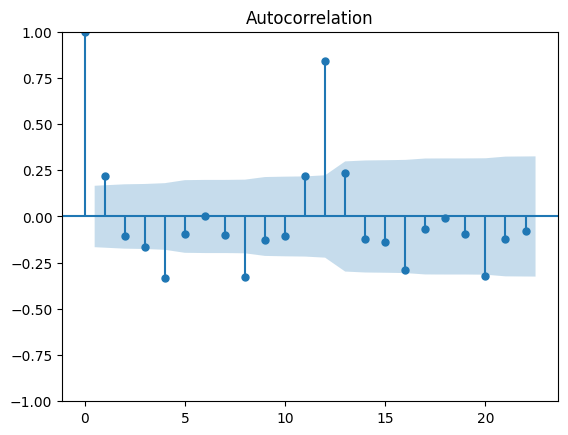

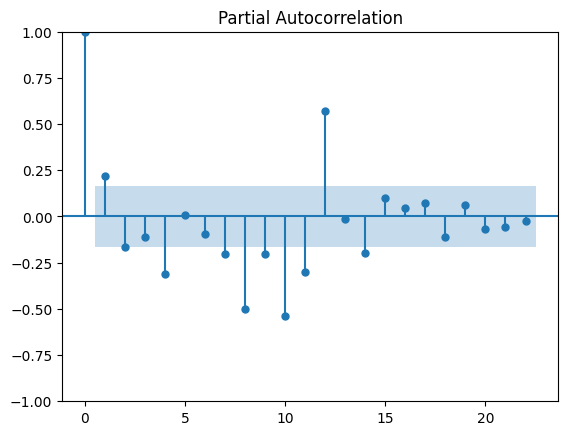

In [203]:
data["Passenger_diff"] = data["Passengers_Boxcox"].diff()
data.dropna(inplace=True)

# Plot acf and pacf
plot_acf(data['Passenger_diff'])
plot_pacf(data['Passenger_diff'], method='ywm')
plt.show()

In [204]:
# Import packages
from statsmodels.tsa.arima.model import ARIMA
from scipy.special import inv_boxcox

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Build ARIMA model and inverse the boxcox
model = ARIMA(train['Passengers_Boxcox'], 
              order=(12, 1, 12)).fit()
boxcox_forecasts = model.forecast(len(test))

forecasts = inv_boxcox(boxcox_forecasts, lam)

c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autore

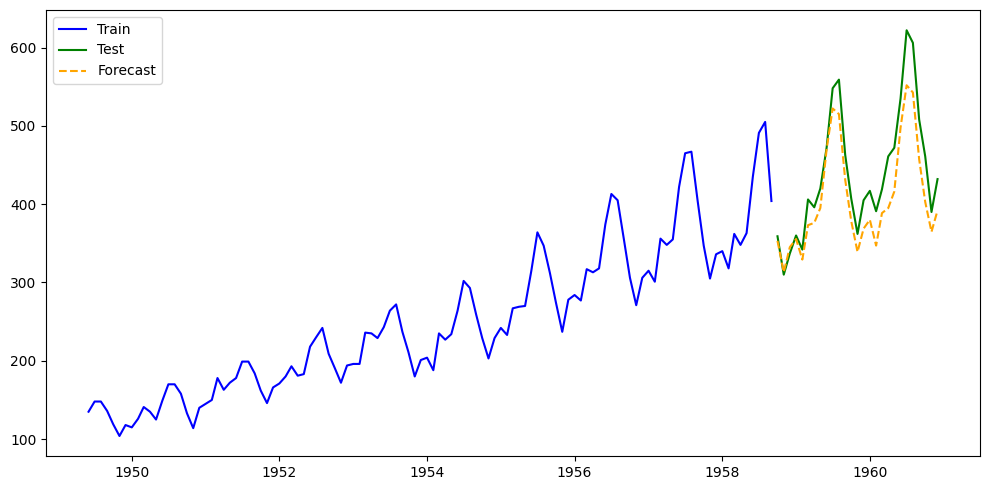

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train['#Passengers'], label='Train', color='blue')
plt.plot(test.index, test['#Passengers'], label='Test', color='green')

# Plot forecast
plt.plot(test.index, forecasts, label='Forecast', linestyle='--', color='orange')
plt.legend()
plt.tight_layout()
plt.show()

# SARIMA

> - SARIMA is an extension of the regular ARIMA model that adds a seasonality component to the model.
> - SARIMA adds a seasonality component to each factor of the ARIMA equation to produce SARIMA(p, d, q)(P, D, Q)m,
$$
y'_t = c + \sum_{n=1}^{p} \phi_n y'_{t-n} + \sum_{n=1}^{q} \theta_n \epsilon_{t-n} + \sum_{n=1}^{P} \eta_n y'_{t-mm} + \sum_{n=1}^{Q} \omega_n \epsilon_{t-mm} + \epsilon_t
$$

In [207]:
# Read in the data
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])
data.set_index("Month", inplace=True)

In [208]:
from scipy.stats import boxcox

# Make the data stationary
data['Passengers_Boxcox'], lam = boxcox(data['#Passengers'])
data["Passenger_diff"] = data["Passengers_Boxcox"].diff()
data.dropna(inplace=True)

<Axes: title={'center': 'Passenger diff'}, xlabel='Month'>

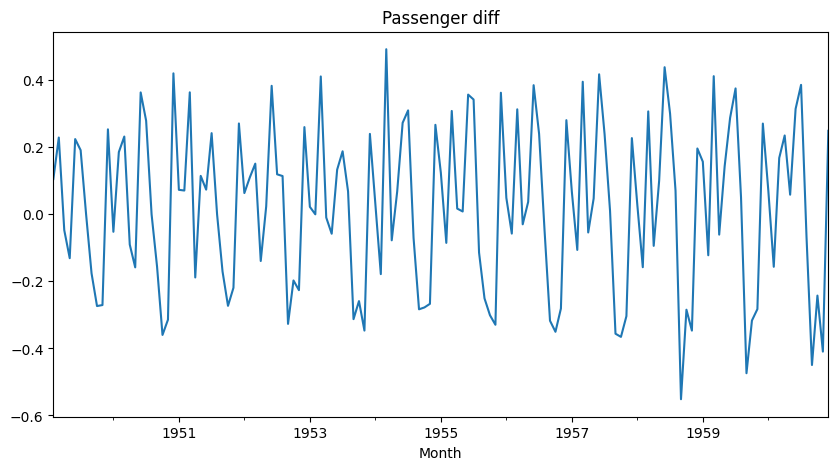

In [209]:
data["Passenger_diff"].plot(title = "Passenger diff", figsize=(10,5))

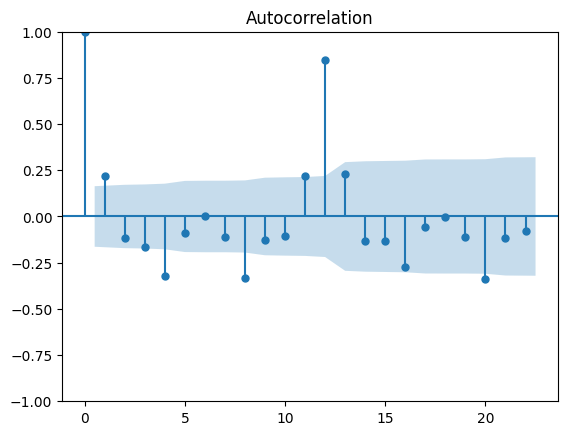

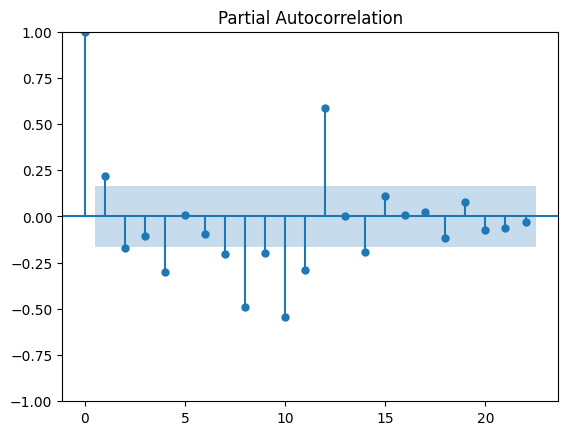

In [210]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

# Plot acf and pacf
plot_acf(data['Passenger_diff'])
plot_pacf(data['Passenger_diff'], method='ywm')
plt.show()

We already observed that our series yearly seasonality, m=12, but the above plots confirm this as we have large spikes at the 12th lags. The lags are also significant to around ~10th lag for both plots. Overall this indicates that a SARIMA(10, 1, 10)(1, 1, 1)12 model should be suitable.

In [211]:
from scipy.special import inv_boxcox
from statsmodels.tsa.arima.model import ARIMA

# Split train and test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Build ARIMA model
model = ARIMA(train['Passengers_Boxcox'], 
              order=(10, 1, 10),
              seasonal_order=(1, 1, 1, 12)).fit()
boxcox_forecasts = model.forecast(len(test))
forecasts = inv_boxcox(boxcox_forecasts, lam)

c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shivam Sharma\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters foun

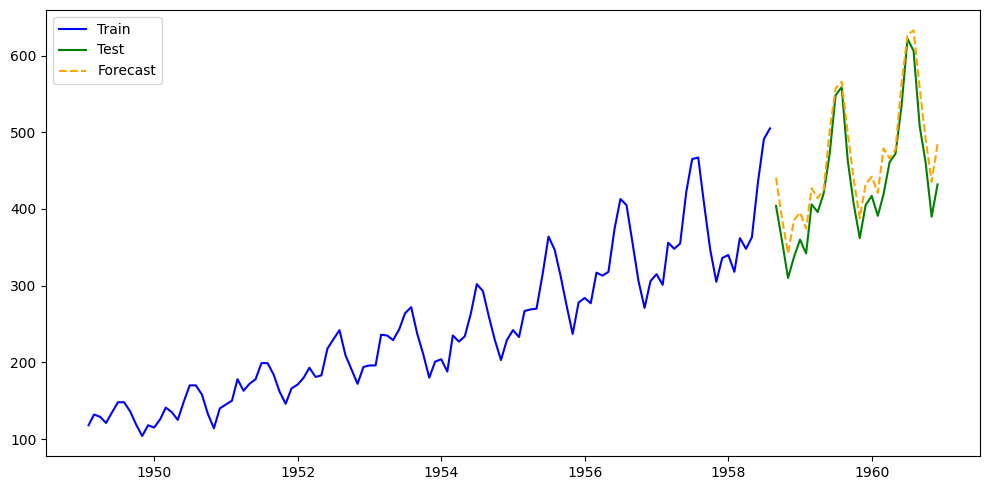

In [212]:
plt.figure(figsize=(10, 5))

plt.plot(train.index, train['#Passengers'], label='Train', color='blue')
plt.plot(test.index, test['#Passengers'], label='Test', color='green')

# Plot forecast
plt.plot(test.index, forecasts, label='Forecast', linestyle='--', color='orange')
plt.legend()
plt.tight_layout()
plt.show()